In [1]:
pip install networkx

Note: you may need to restart the kernel to use updated packages.


In [25]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [26]:
G = nx.Graph()

In [27]:
interactions = [
    ("p53", "MDM2"), ("p53", "ATM"), ("p53", "BRCA1"),
    ("p53", "Bax"), ("ATM", "BRCA1"), ("BRCA1", "BARD1"),
    ("MDM2", "p14ARF"),
    ("p53", "CDKN1A"), ("p53", "PTEN"), ("PTEN", "AKT1"),
    ("AKT1", "MDM2"), ("Bax", "CASP3"), ("ATM", "CHEK2"),
    ("CHEK2", "p53"), ("BRCA1", "CHEK2"), ("CDKN1A", "CASP3")
]

In [28]:
G.add_edges_from(interactions)

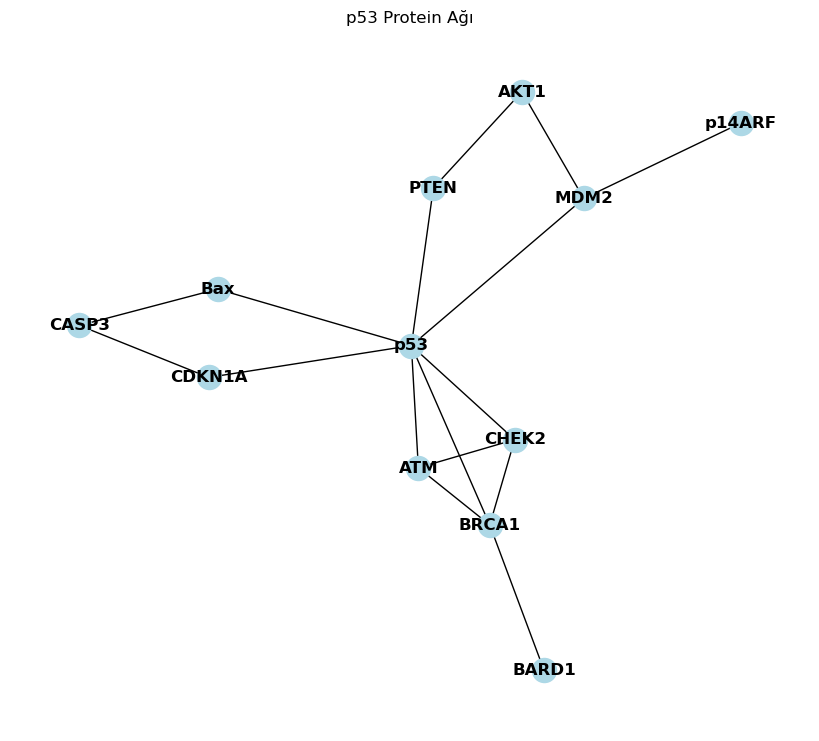

In [29]:
plt.figure(figsize=(8, 7))
nx.draw(G, with_labels=True, node_color='lightblue', font_weight='bold')
plt.title("p53 Protein Ağı")
plt.show()

In [39]:
degree_centrality = nx.degree_centrality(G)
print("Derece Merkeziliği :")
for protein, score in sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True):
    print(f"{protein}: {score:.3f}")

Derece Merkeziliği :
p53: 0.636
BRCA1: 0.364
MDM2: 0.273
ATM: 0.273
CHEK2: 0.273
Bax: 0.182
CDKN1A: 0.182
PTEN: 0.182
AKT1: 0.182
CASP3: 0.182
BARD1: 0.091
p14ARF: 0.091


In [40]:
betweenness_centrality = nx.betweenness_centrality(G)
print("Arasındalık Merkeziliği:")
for protein, score in sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True):
    print(f"{protein}: {score:.3f}")

Arasındalık Merkeziliği:
p53: 0.755
MDM2: 0.255
BRCA1: 0.182
Bax: 0.082
CDKN1A: 0.082
PTEN: 0.073
AKT1: 0.018
CASP3: 0.009
ATM: 0.000
BARD1: 0.000
p14ARF: 0.000
CHEK2: 0.000


In [41]:
node_sizes = [] 
for node in G.nodes(): 
    size = degree_centrality[node] * 7000 
    node_sizes.append(size) 

In [42]:
node_colors = []
for node in G.nodes():
    skor = betweenness_centrality[node]
    node_colors.append(skor)

In [43]:
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

In [44]:
nodes = nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, cmap=plt.cm.coolwarm, alpha=0.9)
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

{'p53': Text(-0.04338236898368351, -0.018286401179046913, 'p53'),
 'MDM2': Text(0.5552543780836365, 0.06682565910537826, 'MDM2'),
 'ATM': Text(-0.42651796168193856, 0.03541878120820461, 'ATM'),
 'BRCA1': Text(-0.5480331070723607, 0.2605892344429879, 'BRCA1'),
 'Bax': Text(0.062467389180389944, -0.5035590732145295, 'Bax'),
 'BARD1': Text(-0.9411591279122695, 0.4901893825514822, 'BARD1'),
 'p14ARF': Text(1.0, 0.002343358918090908, 'p14ARF'),
 'CDKN1A': Text(-0.20327116646497917, -0.4948713785442109, 'CDKN1A'),
 'PTEN': Text(0.2916149289793212, 0.32435096477745623, 'PTEN'),
 'AKT1': Text(0.6426786418750955, 0.4149403767528801, 'AKT1'),
 'CASP3': Text(-0.09039082726430292, -0.8314730952469999, 'CASP3'),
 'CHEK2': Text(-0.29926077873890955, 0.25353219042830755, 'CHEK2')}

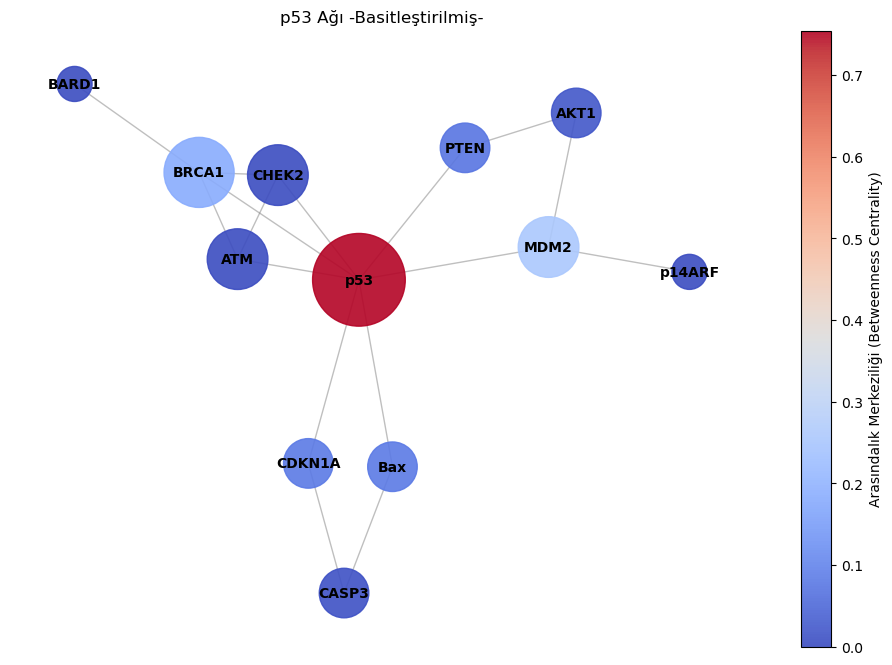

In [45]:
plt.colorbar(nodes, label="Arasındalık Merkeziliği (Betweenness Centrality)")
plt.title("p53 Ağı -Basitleştirilmiş-")
plt.axis('off')
plt.show()

In [109]:
import requests

In [110]:
string_api_url = "https://string-db.org/api/json/network"
params = {
    "identifiers": "TP53",      
    "species": 9606,            
    "limit": 40,                
    "caller_identity": "api_test_project" 
}

In [111]:
response = requests.get(string_api_url, params=params)
api_data = response.json()

In [112]:
G_real = nx.Graph()

for etkilesim in api_data:
    protein_a = etkilesim["preferredName_A"]
    protein_b = etkilesim["preferredName_B"]
    skor = etkilesim["score"] 
    
    G_real.add_edge(protein_a, protein_b, weight=skor)

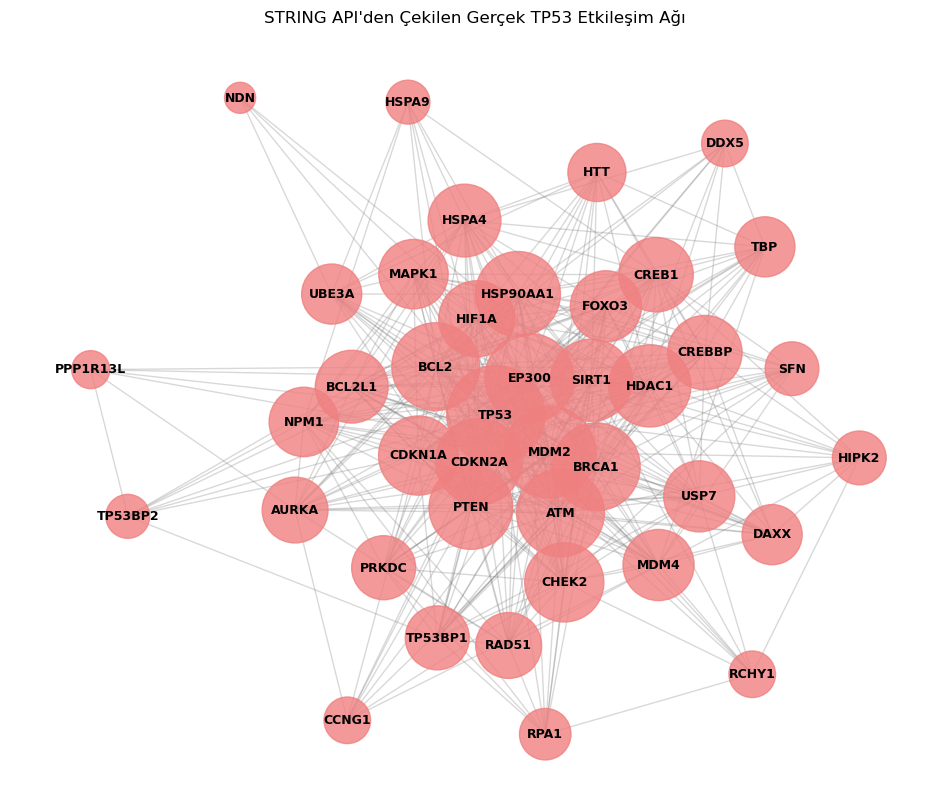

Degree Centrality (En Yüksek 5 - Gerçek Veri):
TP53: 1.000
MDM2: 0.875
EP300: 0.825
BCL2: 0.800
BRCA1: 0.800


Betweenness Centrality (En Yüksek 5 - Gerçek Veri):
TP53: 0.099
MDM2: 0.042
EP300: 0.039
BCL2: 0.036
SIRT1: 0.027


In [113]:
degree_centrality = nx.degree_centrality(G_real)
betweenness_centrality = nx.betweenness_centrality(G_real)
node_sizes = [degree_centrality[node] * 5000 for node in G_real.nodes()]

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G_real, k=0.3, seed=42) 

nx.draw_networkx_nodes(G_real, pos, node_size=node_sizes, node_color='lightcoral', alpha=0.8)
nx.draw_networkx_edges(G_real, pos, edge_color='gray', alpha=0.3)
nx.draw_networkx_labels(G_real, pos, font_size=9, font_weight='bold')

plt.title("STRING API'den Çekilen Gerçek TP53 Etkileşim Ağı")
plt.axis('off')
plt.savefig("p53_ag_analizi.png", dpi=300, bbox_inches='tight')
plt.show()


print("Degree Centrality (En Yüksek 5 - Gerçek Veri):")
for protein, score in sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"{protein}: {score:.3f}")
    
print("\n")

print("Betweenness Centrality (En Yüksek 5 - Gerçek Veri):")
for protein, score in sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"{protein}: {score:.3f}")

In [159]:
G_filtered = G_real.copy()

In [160]:
degree_centrality = nx.degree_centrality(G_filtered)

In [161]:
limitvalue = 0.7
nodes_to_remove = []
for node, centrality in degree_centrality.items():
    if centrality < limitvalue:
        nodes_to_remove.append(node)
        
G_filtered.remove_nodes_from(nodes_to_remove)

In [162]:
new_centrality = nx.degree_centrality(G_filtered)
node_sizes = [new_centrality[node] * 5000 for node in G_filtered.nodes()]

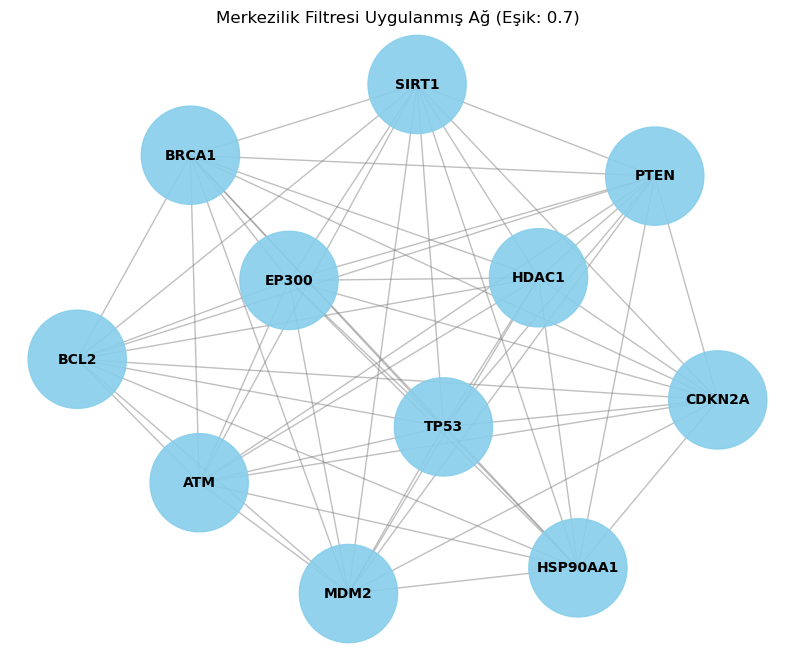

Orijinal düğüm sayısı: 41
Filtreleme sonrası kalan düğüm sayısı: 11


In [163]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_filtered, k=0.5, seed=42)

nx.draw_networkx_nodes(G_filtered, pos, node_size=node_sizes, node_color='skyblue', alpha=0.9)
nx.draw_networkx_edges(G_filtered, pos, edge_color='gray', alpha=0.5)
nx.draw_networkx_labels(G_filtered, pos, font_size=10, font_weight='bold')

plt.title(f"Merkezilik Filtresi Uygulanmış Ağ (Eşik: {limitvalue})")
plt.axis('off')
plt.savefig("Merkezilik Filtresi Uygulanmış Ağ", dpi=300, bbox_inches='tight')
plt.show()

print(f"Orijinal düğüm sayısı: {G_real.number_of_nodes()}")
print(f"Filtreleme sonrası kalan düğüm sayısı: {G_filtered.number_of_nodes()}")

In [164]:
functional_groups = {    
    "CDKN1A": "green", "ATM": "green", "BRCA1": "green", "CHEK2": "green",     
    "BCL2": "red", "BCL2L1": "red", "FOXO3": "red",  
    "MDM2": "blue", "MDM4": "blue", "AKT1": "blue", "PTEN": "blue", "TP53": "gold" 
}

In [165]:
node_colors = []
for node in G_filtered.nodes():
    buyuk_harf_node = node.upper()
    renk = functional_groups.get(buyuk_harf_node, "lightgray")
    node_colors.append(renk)

In [166]:
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_filtered, k=0.6, seed=42)

nodes = nx.draw_networkx_nodes(G_filtered, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9)
nx.draw_networkx_edges(G_filtered, pos, edge_color='gray', alpha=0.4)
nx.draw_networkx_labels(G_filtered, pos, font_size=10, font_weight='bold')

plt.title("Biyolojik Görevlere Göre Renklendirilmiş p53 Ağı")
plt.axis('off')

(np.float64(-1.205572664332057),
 np.float64(1.1634075627326),
 np.float64(-1.0105862790775022),
 np.float64(1.144360625761897))

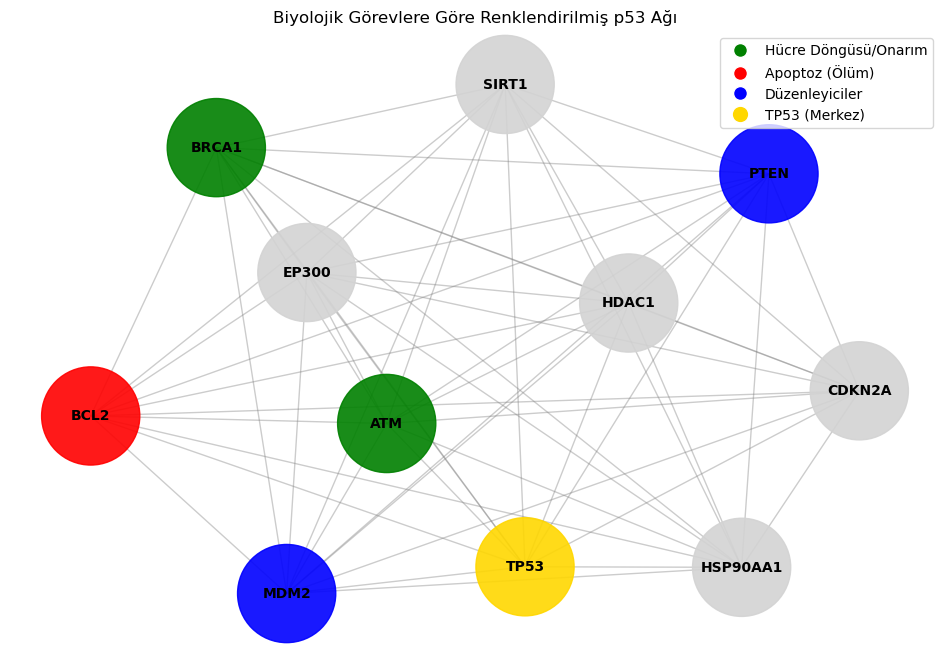

In [167]:
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Hücre Döngüsü/Onarım', markerfacecolor='green', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Apoptoz (Ölüm)', markerfacecolor='red', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Düzenleyiciler', markerfacecolor='blue', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='TP53 (Merkez)', markerfacecolor='gold', markersize=12)]
plt.legend(handles=legend_elements, loc='upper right')

plt.savefig("Biyolojik Görevlere Göre Renklendirilmiş p53 Ağı", dpi=300, bbox_inches='tight')

plt.show()

In [168]:
print("Ağdaki Proteinler:", list(G_filtered.nodes))

Ağdaki Proteinler: ['SIRT1', 'CDKN2A', 'MDM2', 'BCL2', 'PTEN', 'BRCA1', 'HSP90AA1', 'ATM', 'EP300', 'HDAC1', 'TP53']
